In [1]:
# Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Creamos dataframes 
data_equipos = pd.read_excel('info_Tec_limpio.xlsx', sheet_name="Equipos")
data_ordenes = pd.read_excel('info_Tec_limpio.xlsx', sheet_name="Ordenes de trabajo")
data_refacciones = pd.read_excel('info_Tec_limpio.xlsx', sheet_name="Refacciones")

In [3]:
print("Columnas en Equipos:", data_equipos.columns.tolist())
print("Columnas en Ordenes:", data_ordenes.columns.tolist())
print ("Columnas en Refacciones:", data_refacciones.columns.tolist())

Columnas en Equipos: ['EQUIPO', 'MARCA', 'MODELO', 'TIPO']
Columnas en Ordenes: ['Order', 'Main WorkCtr', 'Description', 'Functional Loc.', 'Created On', 'Entered By', 'Changed On', 'Changed By', 'Total act.costs', 'Cost Center', 'User status', 'Order Type', 'Equipment', 'MaintPlant', 'Description.1', 'Plant', 'Revision', 'Work center']
Columnas en Refacciones: ['Order', 'Description', 'G/L Account', 'Amount in LC', 'Plant', 'Purchase order', 'Material Doc.', 'Document Date', 'Material', 'Quantity', 'Currency', 'Posting Date', 'Quantity in UnE', 'Vendor']


In [4]:

# Por equipo, checar cuantas ordenes de trabajo hay en total
conteo_ordenes = data_ordenes.groupby('Equipment').size().reset_index(name='Total_Ordenes')

# Unimos este conteo con nuestro dataframe de equipos
resultado = pd.merge(
    data_equipos, 
    conteo_ordenes, 
    left_on='EQUIPO', 
    right_on='Equipment', 
    how='left'
)
# Cambiar los NaN por 0 (para equipos sin órdenes registradas)
resultado['Total_Ordenes'] = resultado['Total_Ordenes'].fillna(0).astype(int)
# Mostrar el resultado
print(resultado[['EQUIPO', 'Total_Ordenes']])


       EQUIPO  Total_Ordenes
0    30004229             62
1    30004384             48
2    30004399            193
3    30004411            287
4    30004414            118
..        ...            ...
203  30013409             28
204  30013410             23
205  30013411             32
206  30013412             28
207  30013413             17

[208 rows x 2 columns]


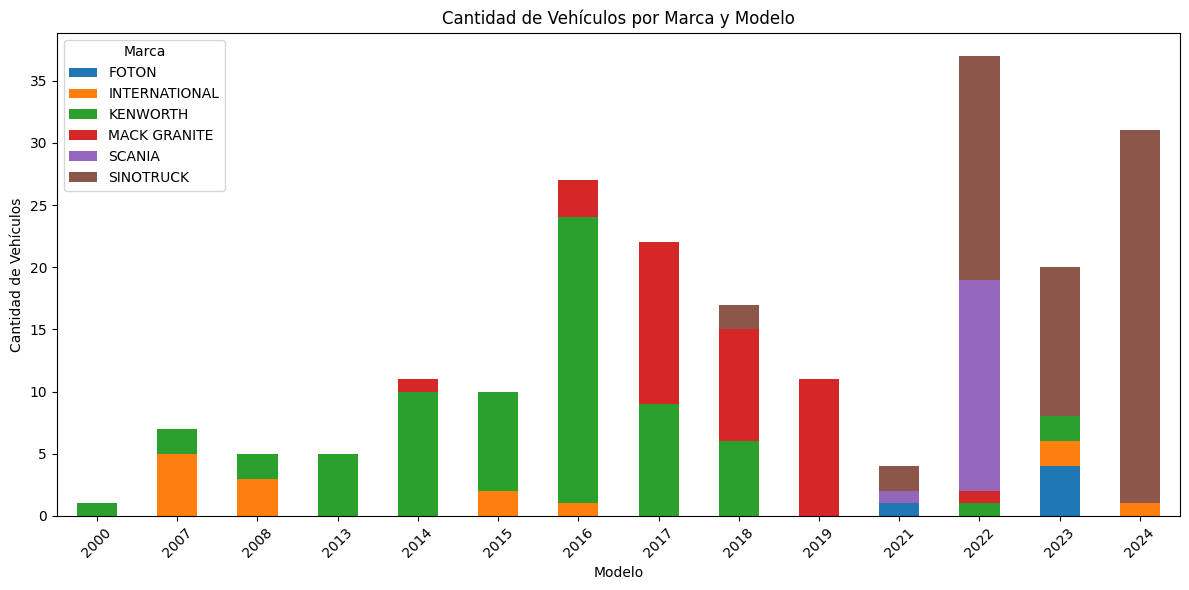

In [5]:
#TODO: cambiar a por maraca todo
#Cantidad de vehiculos por tipo de origen por año
conteo_tipo = data_equipos.groupby(['MARCA', 'MODELO']).size().reset_index(name='Cantidad')

#print(conteo_tipo)

#Grafico de barras apiladas
pivot = conteo_tipo.pivot(
    index='MODELO',
    columns='MARCA',
    values='Cantidad'
).fillna(0)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.xlabel('Modelo')
plt.ylabel('Cantidad de Vehículos')
plt.title('Cantidad de Vehículos por Marca y Modelo')
plt.xticks(rotation=45)
plt.legend(title='Marca', loc='upper left')
plt.tight_layout()
plt.show()

Cantidad de unidades por marca y origen:
           MARCA     ORIGEN  Cantidad
0          FOTON      CHINO         5
1  INTERNATIONAL  AMERICANO        14
2       KENWORTH  AMERICANO        69
3   MACK GRANITE  AMERICANO        38
4         SCANIA    EUROPEO        18
5      SINOTRUCK      CHINO        64


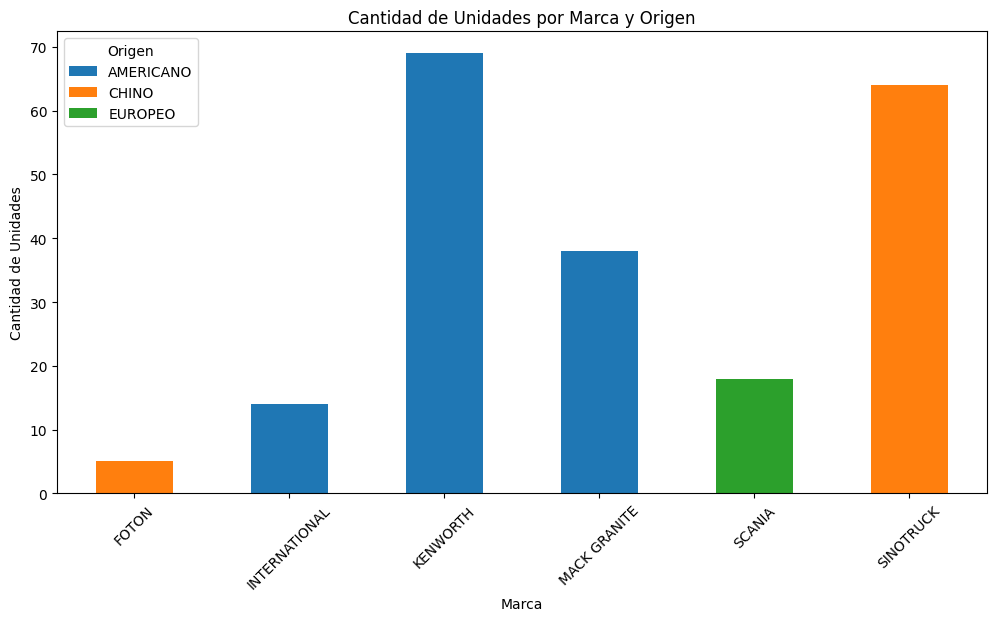

In [6]:
#Cantidad de unidades por marca y origen (tipo)
data_equipos['MARCA'] = data_equipos['MARCA'].fillna('Desconocida')
data_equipos['ORIGEN'] = data_equipos['TIPO'].fillna('Desconocido')
unidades_por_marca_origen = data_equipos.groupby(['MARCA', 'ORIGEN']).size().reset_index(name='Cantidad')
print('Cantidad de unidades por marca y origen:')
print(unidades_por_marca_origen)

#Grafico de barras 
pivot_marca_origen = unidades_por_marca_origen.pivot(
    index='MARCA',
    columns='ORIGEN',
    values='Cantidad'
).fillna(0)
pivot_marca_origen.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.xlabel('Marca')
plt.ylabel('Cantidad de Unidades')
plt.title('Cantidad de Unidades por Marca y Origen')
plt.xticks(rotation=45)
plt.legend(title='Origen', loc='upper left')
plt.show()

           MARCA  Cantidad
0       KENWORTH        69
1      SINOTRUCK        64
2   MACK GRANITE        38
3         SCANIA        18
4  INTERNATIONAL        14
5          FOTON         5


Text(0.5, 1.0, 'Porcentaje de Vehículos por Marca')

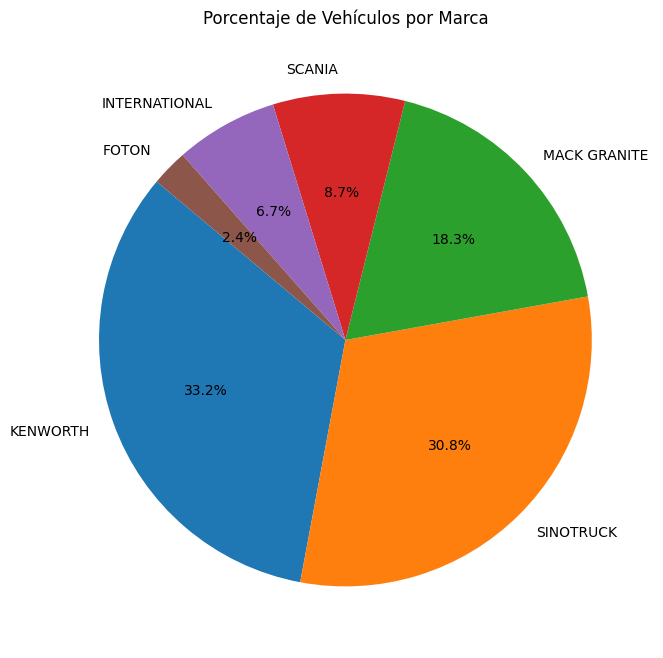

In [7]:
#Porcentaje de vehiculos por tipo
conteo_tipo = data_equipos['MARCA'].value_counts().reset_index()
conteo_tipo.columns = ['MARCA', 'Cantidad']
print(conteo_tipo)

#grafico de pastel
plt.figure(figsize=(8, 8))
plt.pie(conteo_tipo['Cantidad'], labels=conteo_tipo['MARCA'], autopct='%1.1f%%', startangle=140)
plt.title('Porcentaje de Vehículos por Marca')

           MARCA  Total_Ordenes
0          FOTON            407
1  INTERNATIONAL           2057
2       KENWORTH          13066
3   MACK GRANITE           6531
4         SCANIA           1351
5      SINOTRUCK           3307


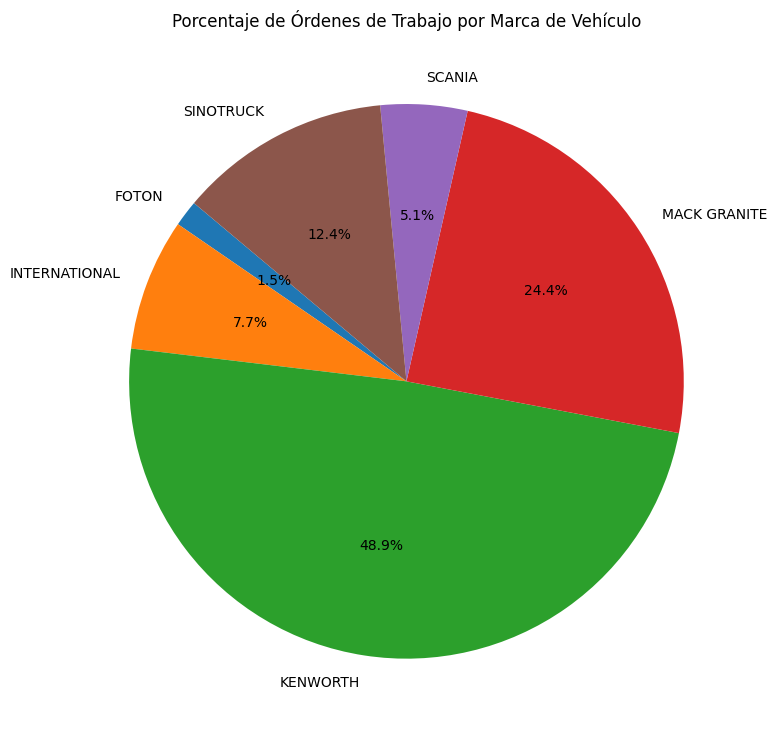

In [8]:
# Por tipo, checar cuantas ordenes de trabajo hay en total
# Primero, obtenemos el conteo de órdenes por equipo (ya tenemos conteo_ordenes de la celda 3)
# Luego, unimos con data_equipos para obtener el TIPO
#IMPORTANTE
conteo_con_tipo = pd.merge(
  data_equipos[['EQUIPO', 'MARCA']], 
  conteo_ordenes, 
  left_on='EQUIPO', 
  right_on='Equipment', 
  how='left'
)

# Ahora, agrupamos por MARCA y sumamos las órdenes totales
conteo_tipo = conteo_con_tipo.groupby('MARCA')['Total_Ordenes'].sum().reset_index(name='Total_Ordenes')

# Mostrar el resultado
print(conteo_tipo)
# Gráfico de pastel para mostrar el porcentaje de órdenes por tipo de vehículo
plt.figure(figsize=(8, 8))
plt.pie(conteo_tipo['Total_Ordenes'], labels=conteo_tipo['MARCA'], autopct='%1.1f%%', startangle=140)
plt.title('Porcentaje de Órdenes de Trabajo por Marca de Vehículo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    AÑO  Total_Ordenes
0  2020           2521
1  2021           3115
2  2022           3506
3  2023           5190
4  2024           6539
5  2025           6947
6  2026           1090


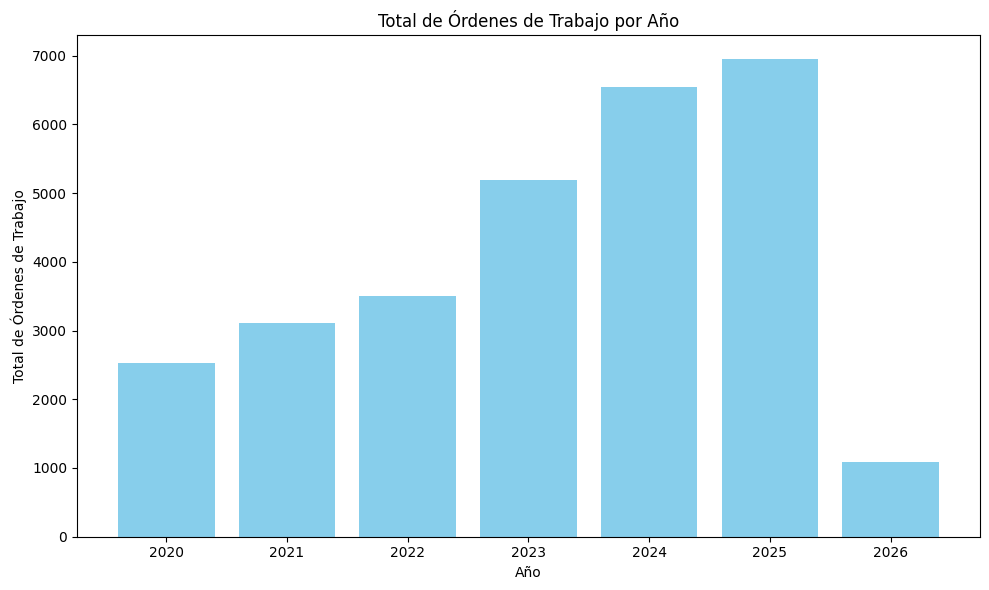

In [9]:
#total de ordenes por año
#IMPORTANTE 2
data_ordenes['AÑO'] = data_ordenes['Created On'].dt.year
conteo_año = data_ordenes.groupby('AÑO').size().reset_index(name='Total_Ordenes')
print(conteo_año)
# Gráfico de barras para mostrar el total de órdenes por año
plt.figure(figsize=(10, 6))
plt.bar(conteo_año['AÑO'], conteo_año['Total_Ordenes'], color='skyblue')
plt.xlabel('Año')
plt.ylabel('Total de Órdenes de Trabajo')
plt.title('Total de Órdenes de Trabajo por Año')
plt.xticks(conteo_año['AÑO'])
plt.tight_layout()
plt.show()

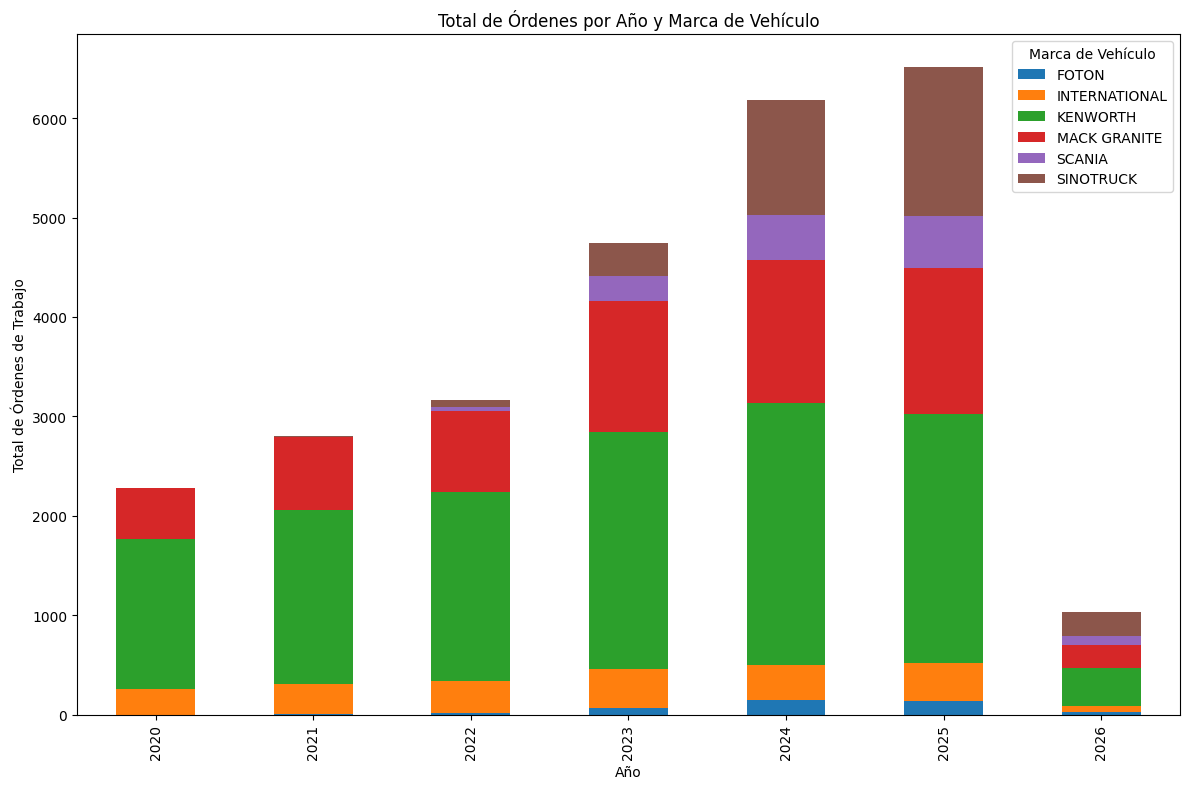

In [10]:
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['AÑO'] = data_ordenes['Created On'].dt.year
ordenes_con_tipo = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
compras_año_tipo = (
    ordenes_con_tipo
    .groupby(['AÑO', 'MARCA'])
    .size()
    .reset_index(name='Total_Ordenes')
)
#print(compras_año_tipo)
pivot = compras_año_tipo.pivot(
    index='AÑO',
    columns='MARCA',
    values='Total_Ordenes'
).fillna(0)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,8)
)

plt.xlabel('Año')
plt.ylabel('Total de Órdenes de Trabajo')
plt.title('Total de Órdenes por Año y Marca de Vehículo')
plt.legend(title='Marca de Vehículo')
plt.tight_layout()
plt.show()

Tiempo promedio de reparación: 195.60 días
Tiempo promedio de reparación por tipo de vehículo en todos los años
           MARCA  Tiempo_Promedio
0          FOTON       134.143921
1  INTERNATIONAL       217.709630
2       KENWORTH       213.918246
3   MACK GRANITE       201.980683
4         SCANIA       140.198042
5      SINOTRUCK       118.387926


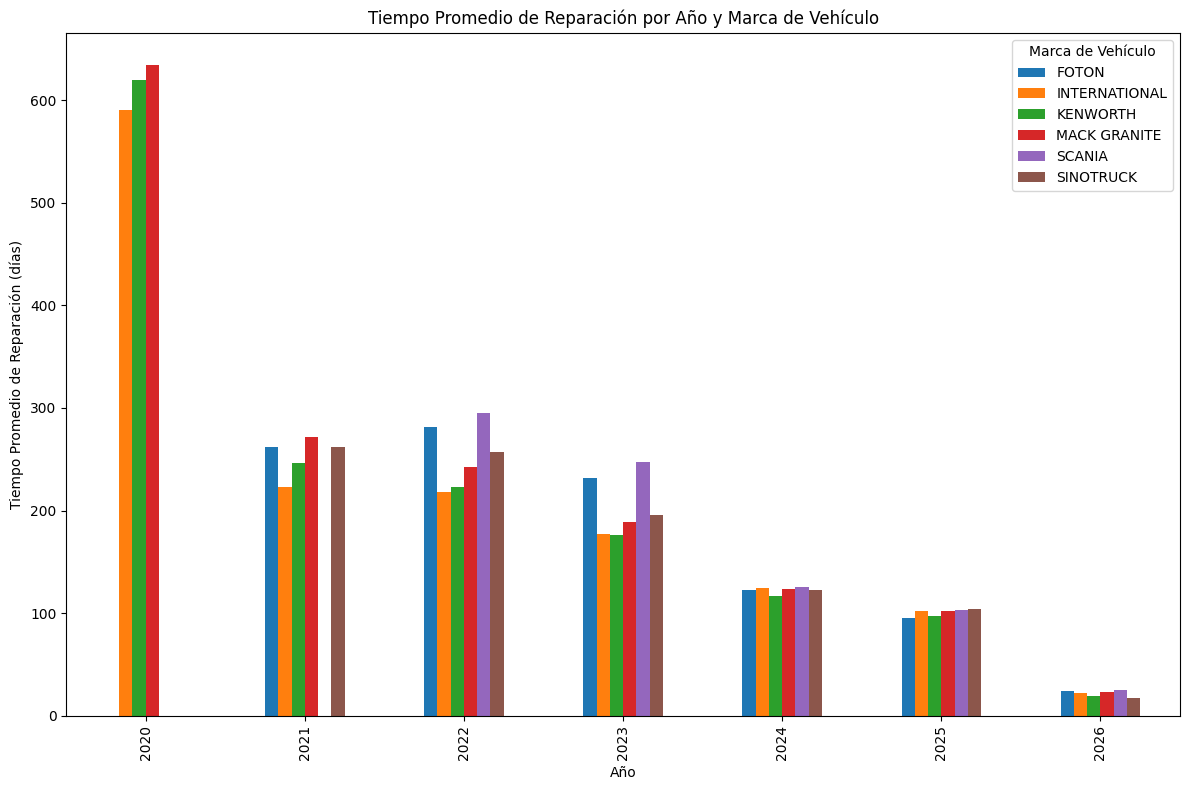

In [11]:
#Tiempo promedio de reparación de vehiculos
#IMPORTANTE 3
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Closed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')
data_ordenes['Tiempo_Reparacion'] = (data_ordenes['Closed On'] - data_ordenes['Created On']).dt.days
tiempo_promedio = data_ordenes['Tiempo_Reparacion'].mean()
print(f'Tiempo promedio de reparación: {tiempo_promedio:.2f} días')

#Tiempo de reparación por tipo de vehículo
ordenes_con_tipo = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
tiempo_tipo = ordenes_con_tipo.groupby('MARCA')['Tiempo_Reparacion'].mean().reset_index(name='Tiempo_Promedio')
print('Tiempo promedio de reparación por tipo de vehículo en todos los años')
print(tiempo_tipo)

#Tiempo promedio por tipo de vehículo gráfico por año
ordenes_con_tipo_año = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
ordenes_con_tipo_año['AÑO'] = ordenes_con_tipo_año['Created On'].dt.year
tiempo_año_tipo = ordenes_con_tipo_año.groupby(['AÑO', 'MARCA'])['Tiempo_Reparacion'].mean().reset_index(name='Tiempo_Promedio')

#print('Tiempo promedio de reparacion por tipo y ano')
# print(tiempo_año_tipo)

pivot = tiempo_año_tipo.pivot(
    index='AÑO',
    columns='MARCA',
    values='Tiempo_Promedio'
).fillna(0)
pivot.plot(
    kind='bar',
    stacked=False,
    figsize=(12,8)
)
plt.xlabel('Año')
plt.ylabel('Tiempo Promedio de Reparación (días)')
plt.title('Tiempo Promedio de Reparación por Año y Marca de Vehículo')
plt.legend(title='Marca de Vehículo')
plt.tight_layout()
plt.show()

In [12]:
#TODO: TIENE QUE SER EL MAX DE 380?
#dame el tiempo mayor de reparación 
tiempo_maximo = data_ordenes['Tiempo_Reparacion'].max()
print(f'Tiempo máximo de reparación: {tiempo_maximo} días')

Tiempo máximo de reparación: 1884.0 días


Cantidad de órdenes por marca y origen:
           MARCA       TIPO  Total_Ordenes
0          FOTON      CHINO            407
1  INTERNATIONAL  AMERICANO           2057
2       KENWORTH  AMERICANO          13066
3   MACK GRANITE  AMERICANO           6531
4         SCANIA    EUROPEO           1351
5      SINOTRUCK      CHINO           3307


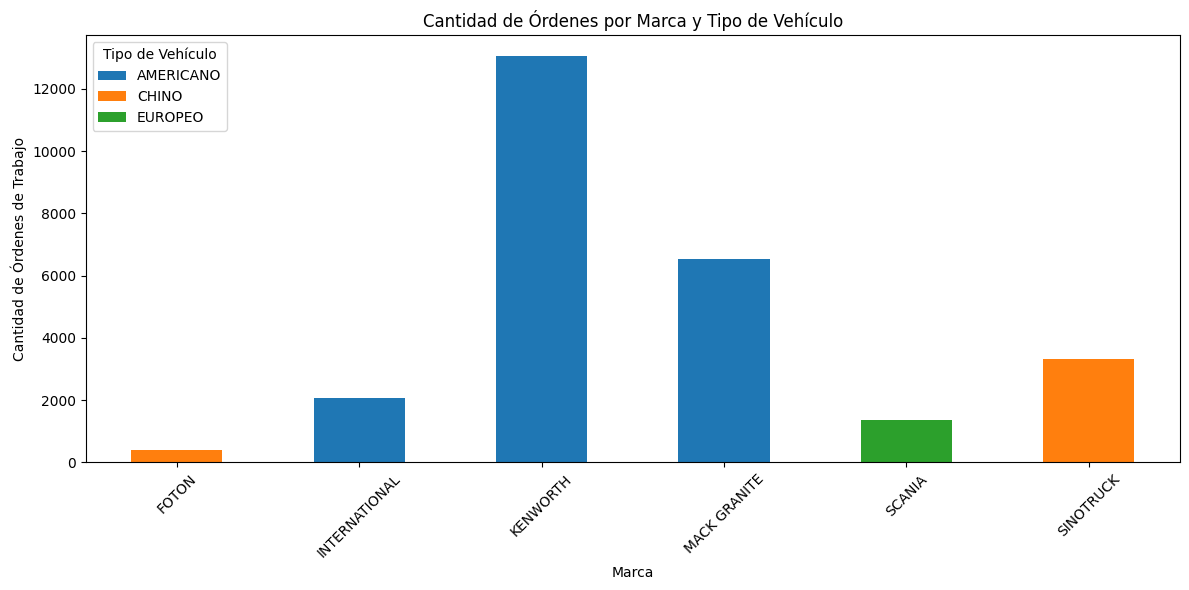

In [13]:
#marcas con mas ordenes y el origen(tipo)
#IMPORTANTE 1
ordenes_con_marca = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'MARCA', 'TIPO']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
ordenes_marca = ordenes_con_marca.groupby(['MARCA', 'TIPO']).size().reset_index(name='Total_Ordenes')
print('Cantidad de órdenes por marca y origen:')
print(ordenes_marca)

pivot_marca_tipo = ordenes_marca.pivot(
    index='MARCA',
    columns='TIPO',
    values='Total_Ordenes'
).fillna(0)
pivot_marca_tipo.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.xlabel('Marca')
plt.ylabel('Cantidad de Órdenes de Trabajo')
plt.title('Cantidad de Órdenes por Marca y Tipo de Vehículo')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Vehículo', loc='upper left')
plt.tight_layout()
plt.show()

Tiempo promedio de reparación por año:
    AÑO  Tiempo_Promedio
0  2020       617.647759
1  2021       247.132905
2  2022       228.186823
3  2023       183.650096
4  2024       121.102878
5  2025       100.598989
6  2026        20.531126


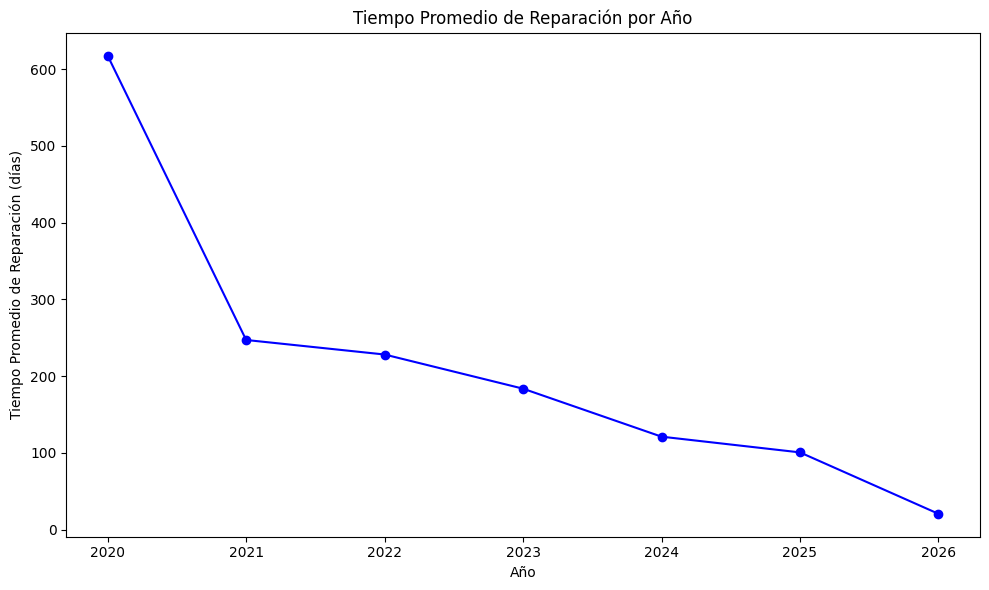

In [14]:
#Tiempo promedio por año.
tiempo_año = data_ordenes.groupby('AÑO')['Tiempo_Reparacion'].mean().reset_index(name='Tiempo_Promedio')
print('Tiempo promedio de reparación por año:')
print(tiempo_año)
plt.figure(figsize=(10, 6))
plt.plot(tiempo_año['AÑO'], tiempo_año['Tiempo_Promedio'], marker='o', linestyle='-', color='blue')
plt.xlabel('Año')
plt.ylabel('Tiempo Promedio de Reparación (días)')
plt.title('Tiempo Promedio de Reparación por Año')
plt.xticks(tiempo_año['AÑO'])
plt.tight_layout()
plt.show()


     AÑO          MARCA  Duracion_dias
0   2020  INTERNATIONAL     591.007812
1   2020       KENWORTH     620.238064
2   2020   MACK GRANITE     634.157996
3   2021          FOTON     262.000000
4   2021  INTERNATIONAL     222.596774
5   2021       KENWORTH     246.728211
6   2021   MACK GRANITE     271.603774
7   2021      SINOTRUCK     262.000000
8   2022          FOTON     281.166667
9   2022  INTERNATIONAL     218.380503
10  2022       KENWORTH     222.514945
11  2022   MACK GRANITE     242.873606
12  2022         SCANIA     295.081633
13  2022      SINOTRUCK     257.015625
14  2023          FOTON     231.436620
15  2023  INTERNATIONAL     177.148825
16  2023       KENWORTH     176.038928
17  2023   MACK GRANITE     188.717095
18  2023         SCANIA     247.567901
19  2023      SINOTRUCK     195.455621
20  2024          FOTON     122.463576
21  2024  INTERNATIONAL     124.173295
22  2024       KENWORTH     116.847677
23  2024   MACK GRANITE     123.204451
24  2024         SCANIA  

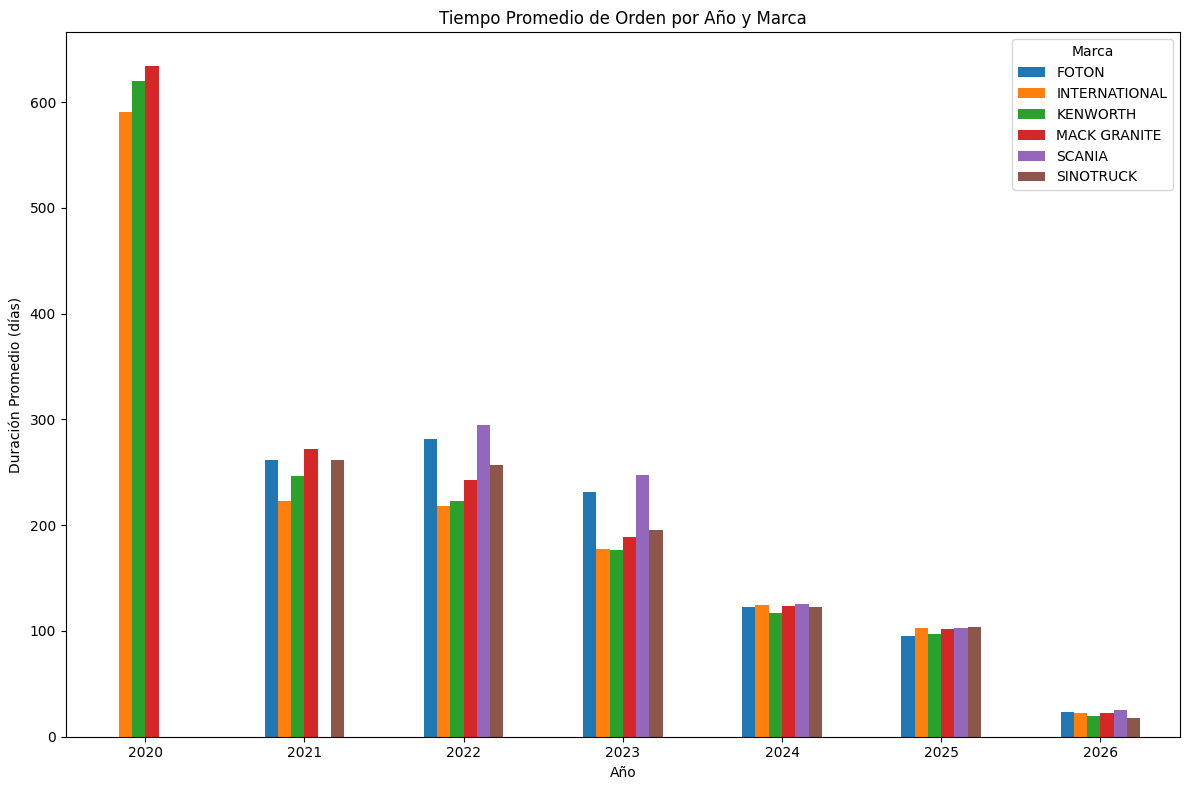

In [15]:
#Tiempo promedio por año y por tipo().
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')

data_ordenes['Duracion_dias'] = (
    data_ordenes['Changed On'] - data_ordenes['Created On']
).dt.days


data_ordenes['AÑO'] = data_ordenes['Created On'].dt.year

ordenes_con_tipo = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)

tiempo_promedio = (
    ordenes_con_tipo
    .groupby(['AÑO', 'MARCA'])['Duracion_dias']
    .mean()
    .reset_index()
)

print(tiempo_promedio)

pivot = tiempo_promedio.pivot(
    index='AÑO',
    columns='MARCA',
    values='Duracion_dias'
).fillna(0)

pivot.plot(
    kind='bar',
    stacked=False,   
    figsize=(12,8)
)

plt.xlabel('Año')
plt.ylabel('Duración Promedio (días)')
plt.title('Tiempo Promedio de Orden por Año y Marca')
plt.legend(title='Marca')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlación Edad vs Órdenes: 0.7239269911705455


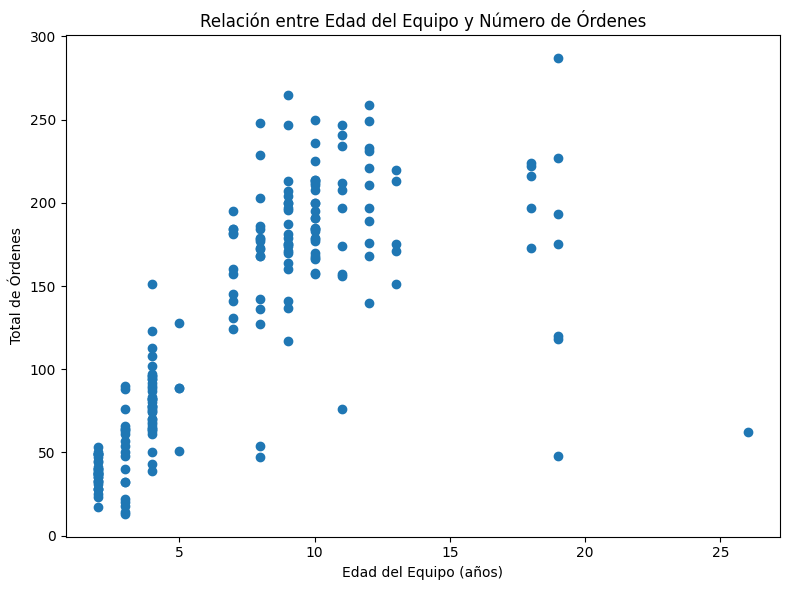

In [16]:
#¿Los equipos más antiguos generan más órdenes? (IMPORTANTE)
año_actual = pd.Timestamp.now().year

data_equipos['Edad'] = año_actual - data_equipos['MODELO']

ordenes_por_equipo = (
    data_ordenes
    .groupby('Equipment')
    .size()
    .reset_index(name='Total_Ordenes')
)

analisis = pd.merge(
    data_equipos[['EQUIPO', 'Edad']],
    ordenes_por_equipo,
    left_on='EQUIPO',
    right_on='Equipment',
    how='left'
)

analisis['Total_Ordenes'] = analisis['Total_Ordenes'].fillna(0)

correlacion = analisis['Edad'].corr(analisis['Total_Ordenes'])
print("Correlación Edad vs Órdenes:", correlacion)

plt.figure(figsize=(8,6))
plt.scatter(analisis['Edad'], analisis['Total_Ordenes'])

plt.xlabel('Edad del Equipo (años)')
plt.ylabel('Total de Órdenes')
plt.title('Relación entre Edad del Equipo y Número de Órdenes')
plt.tight_layout()
plt.show()

   Equipment  Duracion_dias      EQUIPO  Edad
0   30004414          766.0  30004414.0  19.0
1   30004415          766.0  30004415.0  19.0
2   30004415          745.0  30004415.0  19.0
3   30004414          740.0  30004414.0  19.0
4   30004414          687.0  30004414.0  19.0
Correlación Edad vs Tiempo de reparación: 0.18835149889549668


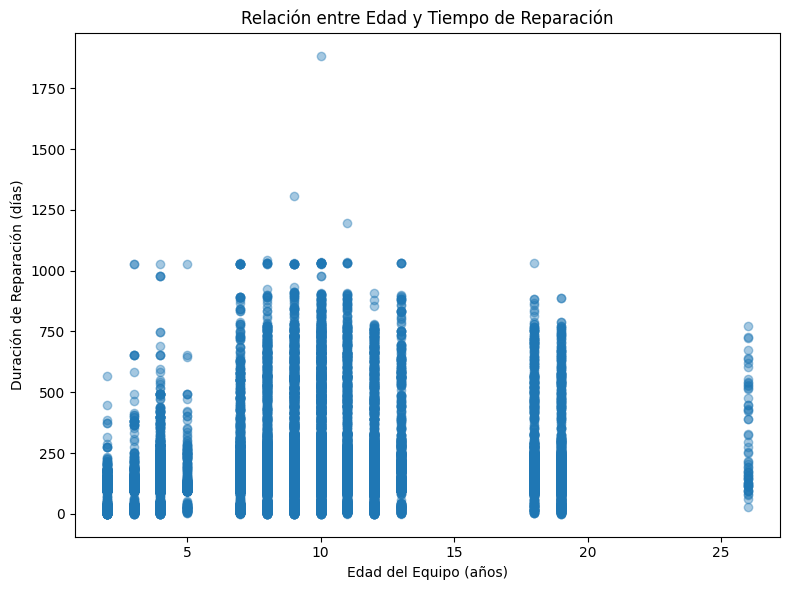

In [17]:
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')

# =========================
# 2️⃣ Calcular duración en días
# =========================
data_ordenes['Duracion_dias'] = (
    data_ordenes['Changed On'] - data_ordenes['Created On']
).dt.days

# Eliminar negativos o nulos
data_ordenes = data_ordenes[data_ordenes['Duracion_dias'] >= 0]


año_actual = pd.Timestamp.now().year
data_equipos['Edad'] = año_actual - data_equipos['MODELO']

analisis = pd.merge(
    data_ordenes[['Equipment', 'Duracion_dias']],
    data_equipos[['EQUIPO', 'Edad']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)

analisis = analisis.dropna(subset=['Edad'])

print(analisis.head())

correlacion = analisis['Edad'].corr(analisis['Duracion_dias'])
print("Correlación Edad vs Tiempo de reparación:", correlacion)

plt.figure(figsize=(8,6))
plt.scatter(analisis['Edad'], analisis['Duracion_dias'], alpha=0.4)

plt.xlabel('Edad del Equipo (años)')
plt.ylabel('Duración de Reparación (días)')
plt.title('Relación entre Edad y Tiempo de Reparación')
plt.tight_layout()
plt.show()

      Material                            Description  Quantity
791  3000791.0               ACEITE MOBIL DTE 26 19LT   21756.0
782  3000647.0  OIL DELVAC1300 15W40 EXON MOBILE BULK    7905.0
795  3001750.0         ACEITE HIDRAULICO NUNO 68 19LT    7618.0
561  2004570.0  MANGUERA 5/8PUL SER LIGERO ADAPTAFLEX    2621.0
771  3000600.0                                 DIESEL    2565.0
562  2004572.0                  MANGUERA CAPRI 3/4PUL    2475.0
277  1097649.0      LLANTA RENOVADA 11R24.5TRA VM530L    2418.0
783  3000652.0  ACEITE MOBIL DTE 26 208LT - TELLUS 68    2184.0
779  3000641.0            ACEITE MLUBE HD 85W140 19LT    2129.0
797  3001871.0             ACEITE SINOTRUK RLCM 10W40    1640.0


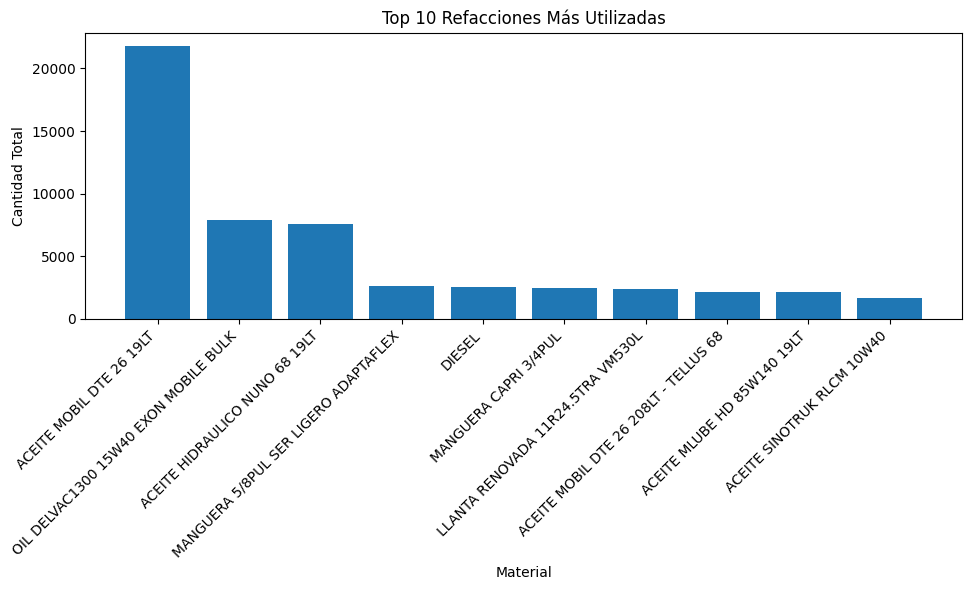

In [18]:
material_info = (
    data_refacciones[['Material', 'Description']]
    .drop_duplicates(subset='Material')
)

refacciones_mas_usadas = (
    data_refacciones
    .groupby('Material')['Quantity']
    .sum()
    .reset_index()
)
refacciones_mas_usadas = pd.merge(
    refacciones_mas_usadas,
    material_info,
    on='Material',
    how='left'
)
top10 = refacciones_mas_usadas.sort_values(
    by='Quantity',
    ascending=False
).head(10)

print(top10[['Material', 'Description', 'Quantity']])

plt.figure(figsize=(10,6))
plt.bar(top10['Description'], top10['Quantity'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Material')
plt.ylabel('Cantidad Total')
plt.title('Top 10 Refacciones Más Utilizadas')
plt.tight_layout()
plt.show()

<Axes: ylabel='Description'>

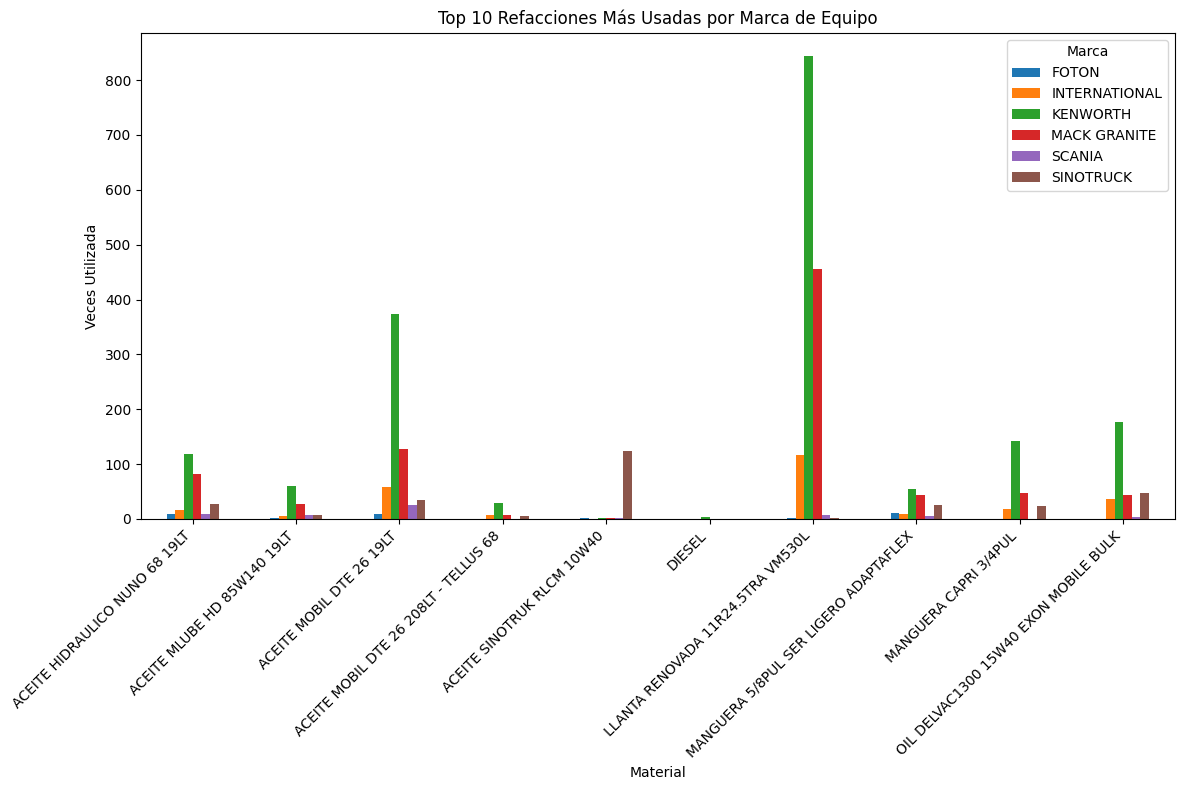

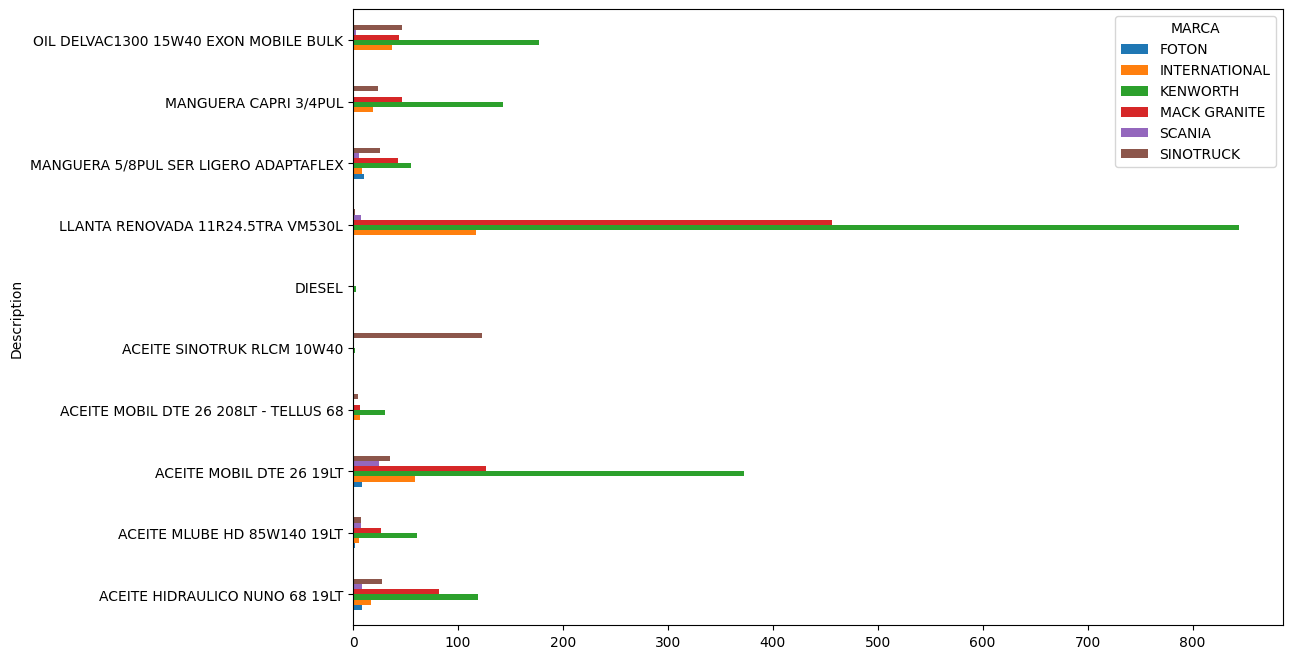

In [19]:
top10_materiales = (
    data_refacciones
    .groupby('Material')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# =========================
# 2️⃣ Filtrar solo esas 10
# =========================
ref_top10 = data_refacciones[
    data_refacciones['Material'].isin(top10_materiales)
]

# =========================
# 3️⃣ Obtener nombre único del material
# =========================
material_info = (
    data_refacciones[['Material', 'Description']]
    .drop_duplicates(subset='Material')
)

# =========================
# 4️⃣ Unir con órdenes
# =========================
ref_top10 = ref_top10.copy()
ref_top10['Order'] = ref_top10['Order'].astype(str)
data_ordenes['Order'] = data_ordenes['Order'].astype(str)

ref_orden = pd.merge(
    ref_top10,
    data_ordenes[['Order', 'Equipment']],
    on='Order',
    how='left'
)

# =========================
# 5️⃣ Unir con equipos
# =========================
ref_completo = pd.merge(
    ref_orden,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)

# =========================
# 6️⃣ Contar uso por Material y MARCA
# =========================
uso_material_tipo = (
    ref_completo
    .groupby(['Material', 'MARCA'])
    .size()
    .reset_index(name='Veces_Usada')
)

# =========================
# 7️⃣ Agregar nombre del material
# =========================
uso_material_tipo = pd.merge(
    uso_material_tipo,
    material_info,
    on='Material',
    how='left'
)

# =========================
# 8️⃣ Pivot usando Description
# =========================
pivot = uso_material_tipo.pivot(
    index='Description',  
    columns='MARCA',
    values='Veces_Usada'
).fillna(0)

# =========================
# 9️⃣ Graficar
# =========================
pivot.plot(
    kind='bar',
    stacked=False,
    figsize=(12,8)
)

plt.xlabel('Material')
plt.ylabel('Veces Utilizada')
plt.title('Top 10 Refacciones Más Usadas por Marca de Equipo')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Marca')
plt.tight_layout()
pivot.plot(kind='barh', figsize=(12,8))


In [20]:
ref_orden = pd.merge(
    data_refacciones,
    data_ordenes[['Order', 'Equipment']],
    on='Order',
    how='left'
)

ref_completo = pd.merge(
    ref_orden,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
conteo = (
    ref_completo
    .groupby(['Material', 'MARCA'])
    .size()
    .reset_index(name='Usos')
)
total_material = (
    conteo
    .groupby('Material')['Usos']
    .sum()
    .reset_index(name='Total_Usos')
)

asociacion = pd.merge(
    conteo,
    total_material,
    on='Material'
)

asociacion['Porcentaje'] = (
    asociacion['Usos'] / asociacion['Total_Usos']
)

asociacion = asociacion.sort_values(
    by='Porcentaje',
    ascending=False
)

print(asociacion.head(30))


       Material          MARCA  Usos  Total_Usos  Porcentaje
3     1048465.0      SINOTRUCK     1           1         1.0
4     1049374.0          FOTON     1           1         1.0
465   1077508.0       KENWORTH     1           1         1.0
466   1078226.0      SINOTRUCK     2           2         1.0
467   1078228.0   MACK GRANITE     1           1         1.0
468   1078879.0       KENWORTH     1           1         1.0
469   1083375.0   MACK GRANITE     1           1         1.0
470   1083857.0   MACK GRANITE     1           1         1.0
474   1084231.0       KENWORTH     1           1         1.0
387   1073407.0       KENWORTH     7           7         1.0
488   1085020.0   MACK GRANITE     1           1         1.0
489   1085043.0      SINOTRUCK     1           1         1.0
495   1085395.0       KENWORTH     1           1         1.0
496   1085549.0       KENWORTH     1           1         1.0
1627  2009044.0       KENWORTH     2           2         1.0
1635  2009077.0       KE

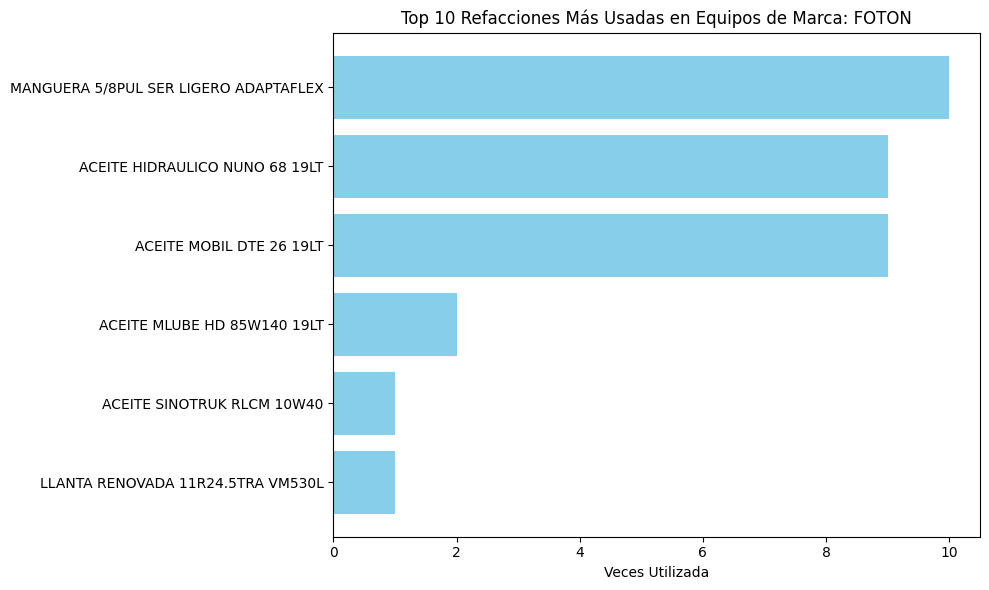

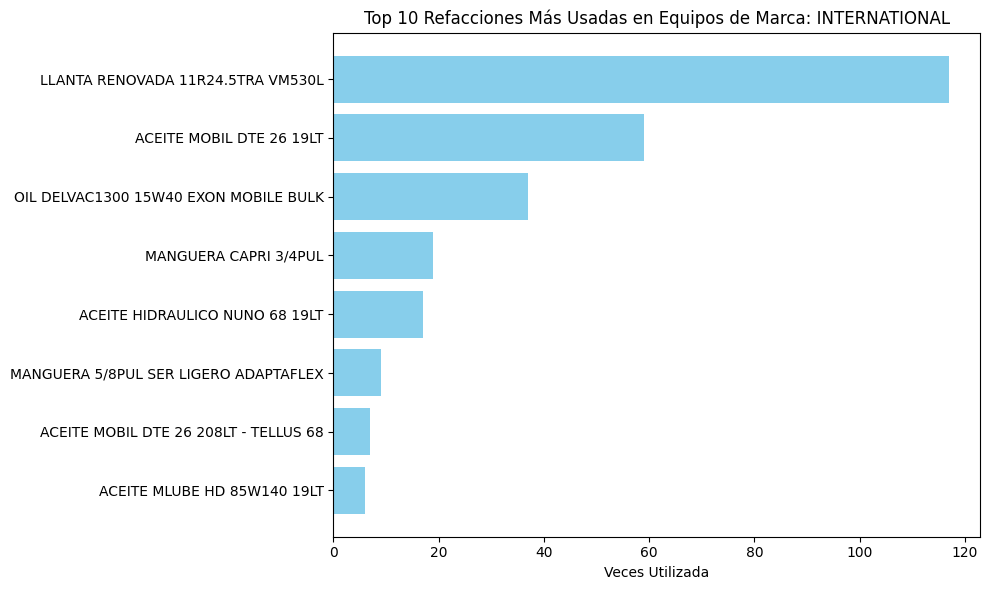

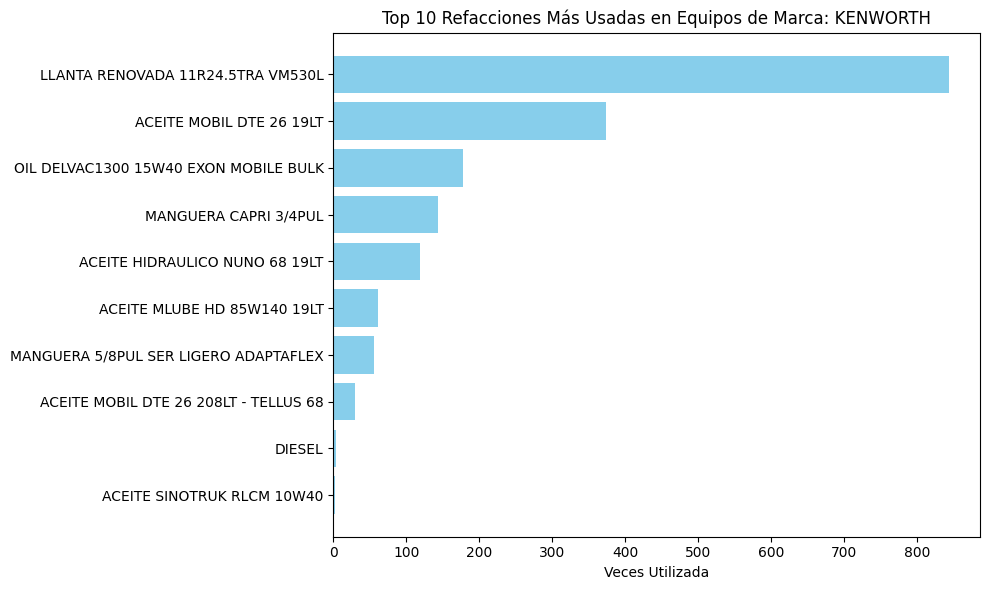

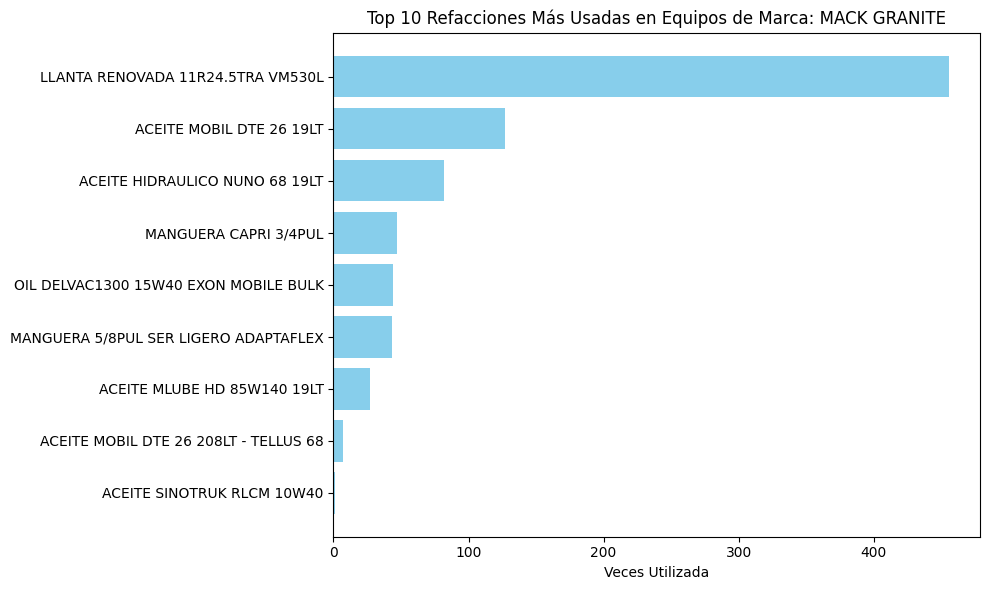

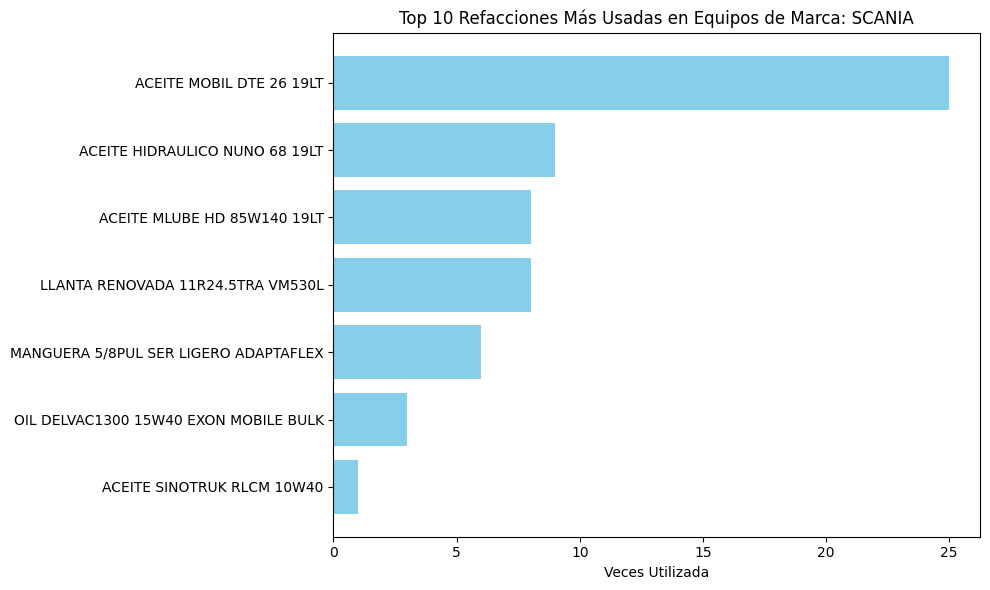

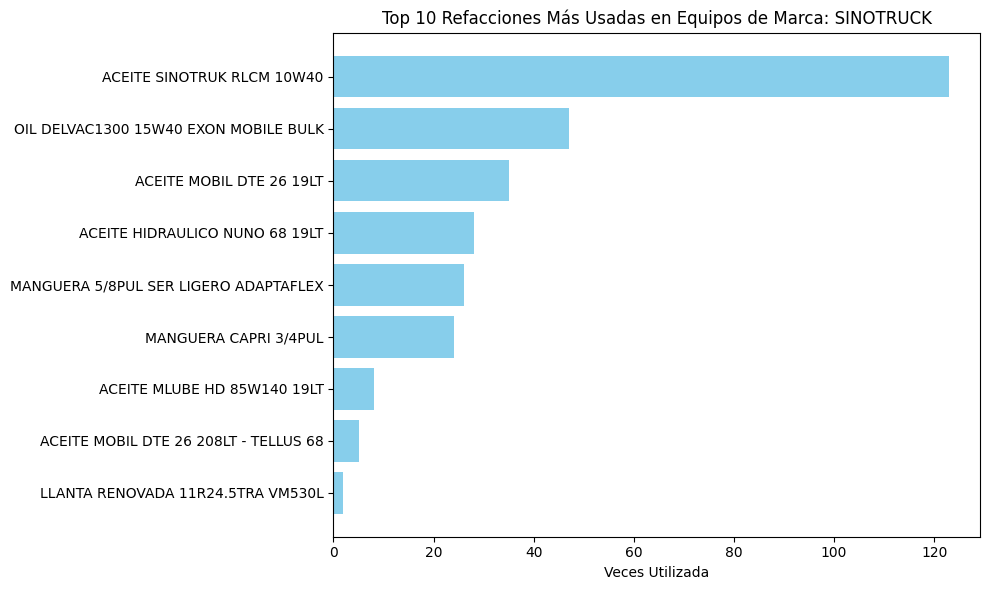

In [21]:
#Top 10 materiales más usados por MARCA de equipo
top10_materiales = (
  data_refacciones
  .groupby('Material')['Quantity']
  .sum()
  .sort_values(ascending=False)
  .head(10)
  .index
)
ref_top10 = data_refacciones[
  data_refacciones['Material'].isin(top10_materiales)
]
material_info = (
  data_refacciones[['Material', 'Description']]
  .drop_duplicates(subset='Material')
)
ref_orden = pd.merge(
  ref_top10,
  data_ordenes[['Order', 'Equipment']],
  on='Order',
  how='left'
)
ref_completo = pd.merge(
  ref_orden,
  data_equipos[['EQUIPO', 'MARCA']],
  left_on='Equipment',
  right_on='EQUIPO',
  how='left'
)
uso_material_tipo = (
  ref_completo
  .groupby(['Material', 'MARCA'])
  .size()
  .reset_index(name='Veces_Usada')
)
uso_material_tipo = pd.merge(
  uso_material_tipo,
  material_info,
  on='Material',
  how='left'
)

#Dividirlas por marca de equipo, para hacer 3 gráficos de barras horizontales
for marca in uso_material_tipo['MARCA'].unique():
    subset = uso_material_tipo[uso_material_tipo['MARCA'] == marca]
    subset = subset.sort_values(by='Veces_Usada', ascending=True)
    
    plt.figure(figsize=(10,6))
    plt.barh(subset['Description'], subset['Veces_Usada'], color='skyblue')
    plt.xlabel('Veces Utilizada')
    plt.title(f'Top 10 Refacciones Más Usadas en Equipos de Marca: {marca}')
    plt.tight_layout()
    plt.show()
    

In [22]:
#Top 10 equipos con más órdenes y su MARCA.
#esto es porque los americanos llevan mas tiempo aun que tambien se deben de descomponer mas por ser mas viejos y que hay mas en circulacion 
equipos_ordenes = (
  data_ordenes
  .groupby('Equipment')
  .size()
  .sort_values(ascending=False)
  .head(10)
)
equipos_ordenes = equipos_ordenes.reset_index(name='Total_Ordenes')
equipos_ordenes = pd.merge(
  equipos_ordenes,
  data_equipos[['EQUIPO', 'MARCA']],
  left_on='Equipment',
  right_on='EQUIPO',
  how='left'
)
print(equipos_ordenes[['Equipment', 'Total_Ordenes', 'MARCA']])

   Equipment  Total_Ordenes         MARCA
0   30004411            287      KENWORTH
1   30004360            277           NaN
2   30004366            273           NaN
3   30007044            261      KENWORTH
4   30005759            252      KENWORTH
5   30005765            248      KENWORTH
6   30006161            247      KENWORTH
7   30010147            245  MACK GRANITE
8   30009430            243      KENWORTH
9   30006598            242      KENWORTH


In [23]:
#Top 10 con mayor tiempo promedio de reparacion, con su tipo de equipo y modelo.

data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')
data_ordenes['Tiempo_Reparacion'] = (data_ordenes['Changed On'] - data_ordenes['Created On']).dt.days
ordenes_con_equipos = pd.merge(
    data_ordenes,
    data_equipos[['EQUIPO', 'TIPO', 'MODELO']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)
tiempo_por_equipo = (
    ordenes_con_equipos
    .groupby(['Equipment', 'TIPO', 'MODELO'])['Tiempo_Reparacion']
    .mean()
    .reset_index(name='Tiempo_Promedio')
)
top10_tiempo = tiempo_por_equipo.sort_values(
    by='Tiempo_Promedio',
    ascending=False
).head(10)
#imprime los 10 americanos, 10 chinos y 10 europeo
top10_americanos = tiempo_por_equipo[tiempo_por_equipo['TIPO'] == 'AMERICANO'].head(10)
top10_chinos = tiempo_por_equipo[tiempo_por_equipo['TIPO'] == 'CHINO'].head(10)
top10_europeos = tiempo_por_equipo[tiempo_por_equipo['TIPO'] == 'EUROPEO'].head(10)

print("Top 10 Americanos con mayor tiempo de reparación:")
print(top10_americanos[['Equipment', 'TIPO', 'MODELO', 'Tiempo_Promedio']])
print("\nTop 10 Chinos con mayor tiempo de reparación:")
print(top10_chinos[['Equipment', 'TIPO', 'MODELO', 'Tiempo_Promedio']])
print("\nTop 10 Europeos con mayor tiempo de reparación:")
print(top10_europeos[['Equipment', 'TIPO', 'MODELO', 'Tiempo_Promedio']])

Top 10 Americanos con mayor tiempo de reparación:
   Equipment       TIPO  MODELO  Tiempo_Promedio
0   30004229  AMERICANO  2000.0       302.677419
1   30004384  AMERICANO  2007.0       121.583333
2   30004399  AMERICANO  2007.0       186.652632
3   30004411  AMERICANO  2007.0       197.731707
4   30004414  AMERICANO  2007.0       232.279279
5   30004415  AMERICANO  2007.0       231.626437
6   30004418  AMERICANO  2007.0       190.400881
7   30004423  AMERICANO  2007.0       269.866667
8   30004428  AMERICANO  2008.0       245.594595
9   30004430  AMERICANO  2008.0       234.660377

Top 10 Chinos con mayor tiempo de reparación:
     Equipment   TIPO  MODELO  Tiempo_Promedio
115   30011601  CHINO  2021.0       145.007874
116   30011666  CHINO  2021.0       151.235294
117   30011667  CHINO  2021.0       126.235955
127   30012223  CHINO  2022.0       129.524390
128   30012224  CHINO  2022.0       121.891304
129   30012225  CHINO  2022.0       132.425532
130   30012226  CHINO  2022.0      

In [24]:
# =============================================================================
# ANÁLISIS DE REFACCIONES CRÍTICAS
# Criterios: Alta frecuencia de uso + Mayor duración promedio en cambio
# =============================================================================

# --- 1. CALCULAR DURACIÓN POR ORDEN ---
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')
data_ordenes['Duracion_dias'] = (data_ordenes['Changed On'] - data_ordenes['Created On']).dt.days
data_ordenes['Order'] = data_ordenes['Order'].astype(str)
data_refacciones['Order'] = data_refacciones['Order'].astype(str)

# --- 2. UNIR REFACCIONES CON DURACIÓN DE ÓRDENES ---
df_criticas = pd.merge(
    data_refacciones[['Order', 'Material', 'Description', 'Quantity', 'Amount in LC']],
    data_ordenes[['Order', 'Equipment', 'Duracion_dias']],
    on='Order',
    how='left'
)

# --- 3. FILTRAR DURACIONES VÁLIDAS (mismo filtro que ya usas) ---
df_criticas = df_criticas[
    (df_criticas['Duracion_dias'] > 0) & 
    (df_criticas['Duracion_dias'] <= 383)
]

# --- 4. AGRUPAR POR MATERIAL ---
resumen = df_criticas.groupby(['Material', 'Description']).agg(
    Frecuencia        = ('Order', 'count'),
    Duracion_Promedio = ('Duracion_dias', 'mean'),
    Duracion_Max      = ('Duracion_dias', 'max'),
    Costo_Promedio    = ('Amount in LC', 'mean'),
    Equipos_Afectados = ('Equipment', 'nunique')
).reset_index()

# --- 5. SCORE DE CRITICIDAD ---
# Normalizamos frecuencia y duración entre 0 y 1, luego combinamos
resumen['Freq_norm']     = (resumen['Frecuencia'] - resumen['Frecuencia'].min()) / (resumen['Frecuencia'].max() - resumen['Frecuencia'].min())
resumen['Dur_norm']      = (resumen['Duracion_Promedio'] - resumen['Duracion_Promedio'].min()) / (resumen['Duracion_Promedio'].max() - resumen['Duracion_Promedio'].min())

# Score: 60% frecuencia + 40% duración
resumen['Score_Criticidad'] = (resumen['Freq_norm'] * 0.6) + (resumen['Dur_norm'] * 0.4)
resumen = resumen.sort_values('Score_Criticidad', ascending=False).reset_index(drop=True)

# Etiqueta de nivel
def nivel_criticidad(score):
    if score >= 0.7:   return '🔴 CRÍTICA'
    elif score >= 0.4: return '🟡 MEDIA'
    else:              return '🟢 BAJA'

resumen['Nivel'] = resumen['Score_Criticidad'].apply(nivel_criticidad)

# --- 6. TABLA TOP 30 ---
print(f"📊 Total de refacciones analizadas: {len(resumen)}")
print(f"🔴 Críticas: {len(resumen[resumen['Nivel'] == '🔴 CRÍTICA'])}  "
      f"🟡 Medias: {len(resumen[resumen['Nivel'] == '🟡 MEDIA'])}  "
      f"🟢 Bajas: {len(resumen[resumen['Nivel'] == '🟢 BAJA'])}")

display(resumen[[
    'Description', 'Nivel', 'Frecuencia', 
    'Duracion_Promedio', 'Duracion_Max', 
    'Costo_Promedio', 'Equipos_Afectados', 'Score_Criticidad'
]].head(10).style.format({
    'Duracion_Promedio':  '{:.1f} días',
    'Duracion_Max':       '{:.0f} días',
    'Costo_Promedio':     '${:,.2f}',
    'Score_Criticidad':   '{:.3f}'
}).background_gradient(subset=['Score_Criticidad'], cmap='RdYlGn_r')
  .background_gradient(subset=['Frecuencia'], cmap='YlOrBr'))

# --- 7. GRÁFICA DE BURBUJAS ---
top40 = resumen.head(40)

fig = px.scatter(
    top40,
    x='Frecuencia',
    y='Duracion_Promedio',
    size='Equipos_Afectados',
    color='Score_Criticidad',
    color_continuous_scale='RdYlGn_r',
    hover_name='Description',
    hover_data={
        'Frecuencia': True,
        'Duracion_Promedio': ':.1f',
        'Costo_Promedio': ':$,.2f',
        'Equipos_Afectados': True,
        'Score_Criticidad': ':.3f'
    },
    title='Refacciones Críticas: Frecuencia vs Duración de Cambio',
    labels={
        'Frecuencia': 'Frecuencia de Uso (veces)',
        'Duracion_Promedio': 'Duración Promedio de Cambio (días)',
        'Score_Criticidad': 'Score'
    }
)

fig.update_layout(
    plot_bgcolor='white',
    title_x=0.5,
    title_font_size=16,
    coloraxis_colorbar=dict(title='Criticidad'),
    width=900,
    height=600
)

# Líneas de referencia para cuadrantes
fig.add_hline(y=top40['Duracion_Promedio'].median(), line_dash='dash', line_color='gray', opacity=0.5)
fig.add_vline(x=top40['Frecuencia'].median(),        line_dash='dash', line_color='gray', opacity=0.5)

fig.show()

# --- 8. EXPORTAR A EXCEL ---
with pd.ExcelWriter('refacciones_criticas.xlsx', engine='openpyxl') as writer:
    
    # Hoja 1: Todas las refacciones con su score
    resumen[[
        'Material', 'Description', 'Nivel', 'Frecuencia',
        'Duracion_Promedio', 'Duracion_Max',
        'Costo_Promedio', 'Equipos_Afectados', 'Score_Criticidad'
    ]].to_excel(writer, sheet_name='Todas', index=False)
    
    # Hoja 2: Solo críticas
    resumen[resumen['Nivel'] == '🔴 CRÍTICA'][[
        'Material', 'Description', 'Nivel', 'Frecuencia',
        'Duracion_Promedio', 'Duracion_Max',
        'Costo_Promedio', 'Equipos_Afectados', 'Score_Criticidad'
    ]].to_excel(writer, sheet_name='Críticas', index=False)
    
    # Hoja 3: Solo medias
    resumen[resumen['Nivel'] == '🟡 MEDIA'][[
        'Material', 'Description', 'Nivel', 'Frecuencia',
        'Duracion_Promedio', 'Duracion_Max',
        'Costo_Promedio', 'Equipos_Afectados', 'Score_Criticidad'
    ]].to_excel(writer, sheet_name='Medias', index=False)

print("✅ Exportado como 'refacciones_criticas.xlsx'")

📊 Total de refacciones analizadas: 758
🔴 Críticas: 1  🟡 Medias: 4  🟢 Bajas: 753


,Description,Nivel,Frecuencia,Duracion_Promedio,Duracion_Max,Costo_Promedio,Equipos_Afectados,Score_Criticidad
0,LLANTA RENOVADA 11R24.5TRA VM530L,🔴 CRÍTICA,1382,168.0 días,365 días,"$4,606.50",131,0.802
1,VALVULA BOLA 3/4PUL CIERRE RAPIDO,🟡 MEDIA,677,163.4 días,375 días,$111.50,162,0.490
2,ACEITE MOBIL DTE 26 19LT,🟡 MEDIA,589,147.1 días,365 días,"$2,623.45",158,0.432
3,CUBIERTA TRAPEADOR MOP 60CM,🟡 MEDIA,2,331.0 días,331 días,$104.90,1,0.400
4,BASE MOPS 60CM,🟡 MEDIA,1,331.0 días,331 días,$130.24,1,0.400
5,TAPON MET P/RADIADOR 10LB BOCA GDE 1852,🟢 BAJA,1,316.0 días,316 días,$180.00,1,0.382
6,CABLE 3X10AWG THW 600V USO RUDO,🟢 BAJA,1,316.0 días,316 días,"$1,917.63",1,0.382
7,BOBINA P/VALVULA 300AA00095A 12V,🟢 BAJA,1,309.0 días,309 días,$712.00,1,0.373
8,ELECTRODO 1/8PUL DURMATIC H-10,🟢 BAJA,1,305.0 días,305 días,$454.84,1,0.368
9,TOALLITAS DESINFECTANTE/ANTIBACTERIAL,🟢 BAJA,1,293.0 días,293 días,$15.20,1,0.354


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed